In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

GOVT_COLOR = '#4c72b0'
PVT_COLOR  = '#dd8452'
GRADES     = list(range(1, 11))

# Load only the columns we need — child_merged.csv is 41 MB / 214k rows
COLS = ['grade', 'school_type', 'province',
        'can_do_division', 'can_read_story_urdu', 'can_read_sentences_english']
raw = pd.read_csv('../Data:/child_merged.csv', usecols=COLS)

df = raw[
    raw['school_type'].isin(['Government', 'Private']) &
    raw['grade'].between(1, 10)
].copy()
df['grade'] = df['grade'].astype(int)

print(f'Rows after filter: {len(df):,}')
print(df.groupby('school_type').size().to_dict())

Rows after filter: 135,181
{'Government': 107896, 'Private': 27285}


In [2]:
# Pre-compute national competency rates by grade × school_type
COMPETENCIES = {
    'can_do_division':           'Can do division (%)',
    'can_read_story_urdu':       'Can read a story in Urdu (%)',
    'can_read_sentences_english':'Can read sentences in English (%)',
}

national = (
    df.groupby(['grade', 'school_type'])[list(COMPETENCIES)]
    .mean()
    .mul(100)
    .reset_index()
)

# Pre-compute province rates for small multiples
PROVINCES_SM = ['Punjab', 'Sindh', 'KPK', 'Balochistan']
province_div = (
    df[df['province'].isin(PROVINCES_SM)]
    .groupby(['province', 'grade', 'school_type'])['can_do_division']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'pct', 'count': 'n'})
    .reset_index()
)
province_div['pct'] = province_div['pct'] * 100

# Private n per province (for footnote)
pvt_n = (
    df[df['province'].isin(PROVINCES_SM) & (df['school_type'] == 'Private')]
    .groupby('province').size()
)
print('Private sample by province (grades 1-10):')
print(pvt_n)

Private sample by province (grades 1-10):
province
Balochistan    1512
KPK            6643
Punjab         8662
Sindh          2182
dtype: int64


In [3]:
def grouped_bar_chart(data, metric, ylabel, title, ax, show_legend=True):
    """Draw a Government vs Private grouped bar chart on ax."""
    govt = data[data['school_type'] == 'Government'].set_index('grade')[metric]
    pvt  = data[data['school_type'] == 'Private'].set_index('grade')[metric]

    x = np.arange(len(GRADES))
    w = 0.38

    ax.bar(x - w / 2, [govt.get(g, np.nan) for g in GRADES],
           width=w, color=GOVT_COLOR, label='Government', zorder=3)
    ax.bar(x + w / 2, [pvt.get(g, np.nan)  for g in GRADES],
           width=w, color=PVT_COLOR,  label='Private',    zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(GRADES)
    ax.set_xlabel('Grade', labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    if show_legend:
        ax.legend(frameon=False, fontsize=10)

## Figure 1 — Division Competency by Grade: Government vs Private (National)

Division is the highest-order arithmetic skill tested in the ASER assessment and serves as a practical threshold for functional numeracy. A child who cannot do two-digit division by grade 5 is almost certainly behind the curriculum by two or more years.

The chart reads as a direct answer to the policy question: **"What percentage of grade-*k* government school students can perform basic division?"** The private school bars provide a same-district counterfactual under better-resourced conditions. The gap between the two bars at each grade is the private advantage — a signal of how much more government school students *could* know under better instruction.

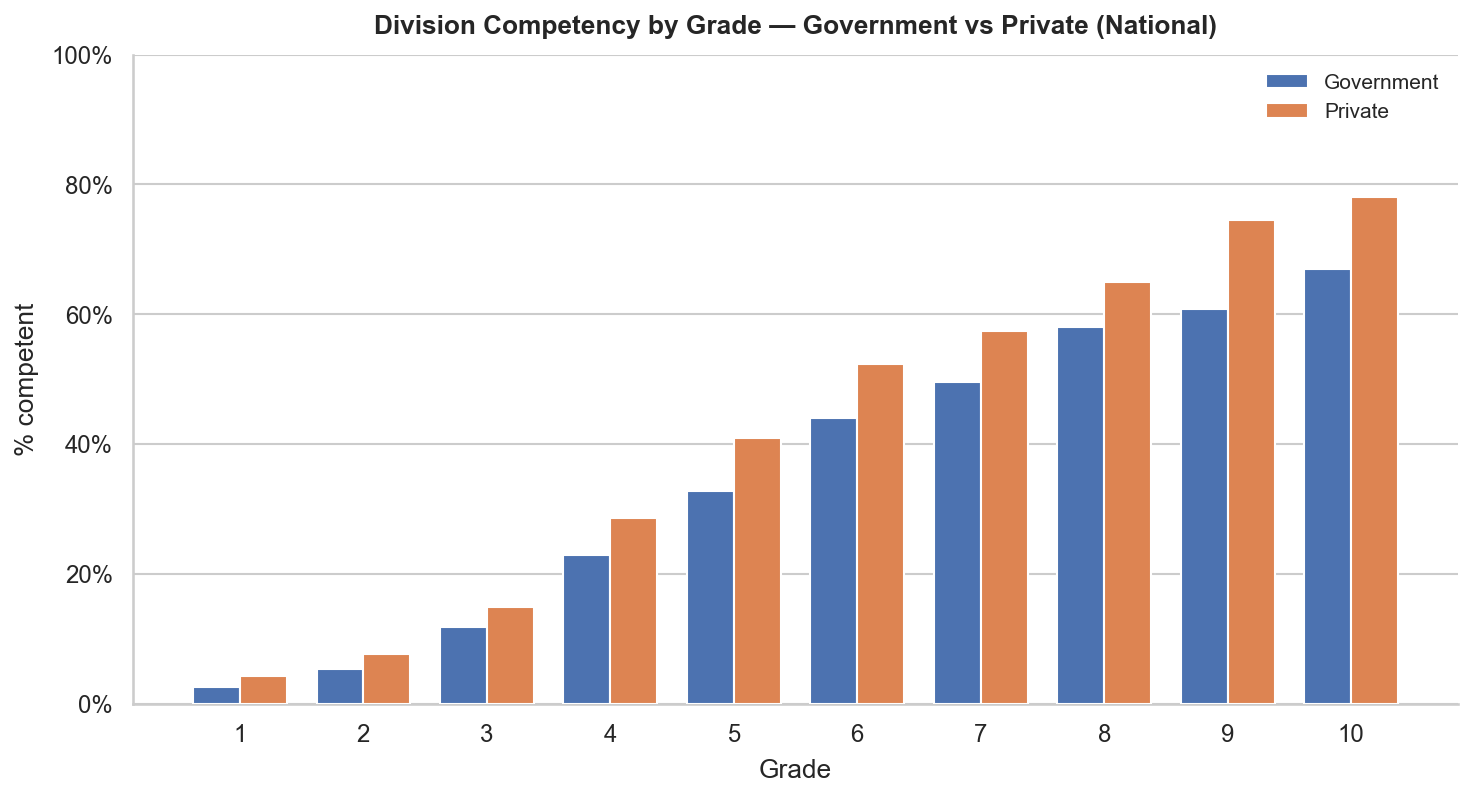

school_type  Government  Private  Gap (pvt−govt)
grade                                           
1                   2.6      4.3             1.7
2                   5.3      7.7             2.4
3                  11.9     14.9             3.0
4                  22.9     28.6             5.7
5                  32.7     40.9             8.2
6                  44.0     52.4             8.4
7                  49.6     57.5             7.9
8                  58.1     65.0             6.9
9                  60.8     74.5            13.7
10                 67.0     78.1            11.1


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
grouped_bar_chart(
    national, 'can_do_division', '% competent',
    'Division Competency by Grade — Government vs Private (National)', ax
)
plt.tight_layout()
fig.savefig(FIGURES / '05a_division_competency_national.png', bbox_inches='tight')
fig.savefig(FIGURES / '05a_division_competency_national.pdf', bbox_inches='tight')
plt.show()

# Print the underlying numbers
tbl = national.pivot(index='grade', columns='school_type', values='can_do_division').round(1)
tbl['Gap (pvt−govt)'] = (tbl['Private'] - tbl['Government']).round(1)
print(tbl.to_string())

## Figure 2 — Urdu Story Reading Competency by Grade: Government vs Private (National)

Reading a complete story in Urdu is the highest literacy tier in the assessment — it requires fluency, not just letter or word recognition. As the medium of instruction in most government schools, Urdu reading proficiency is the single best indicator of whether a child is meaningfully engaged with classroom learning.

Government school rates at grades 1–3 reflect the foundational literacy crisis documented across South Asia: the majority of early-grade children cannot yet read connected text. The closing gap in upper grades (8–10) reflects both genuine skill development and attrition — weaker students are more likely to drop out, so upper-grade samples are positively selected in both sectors.

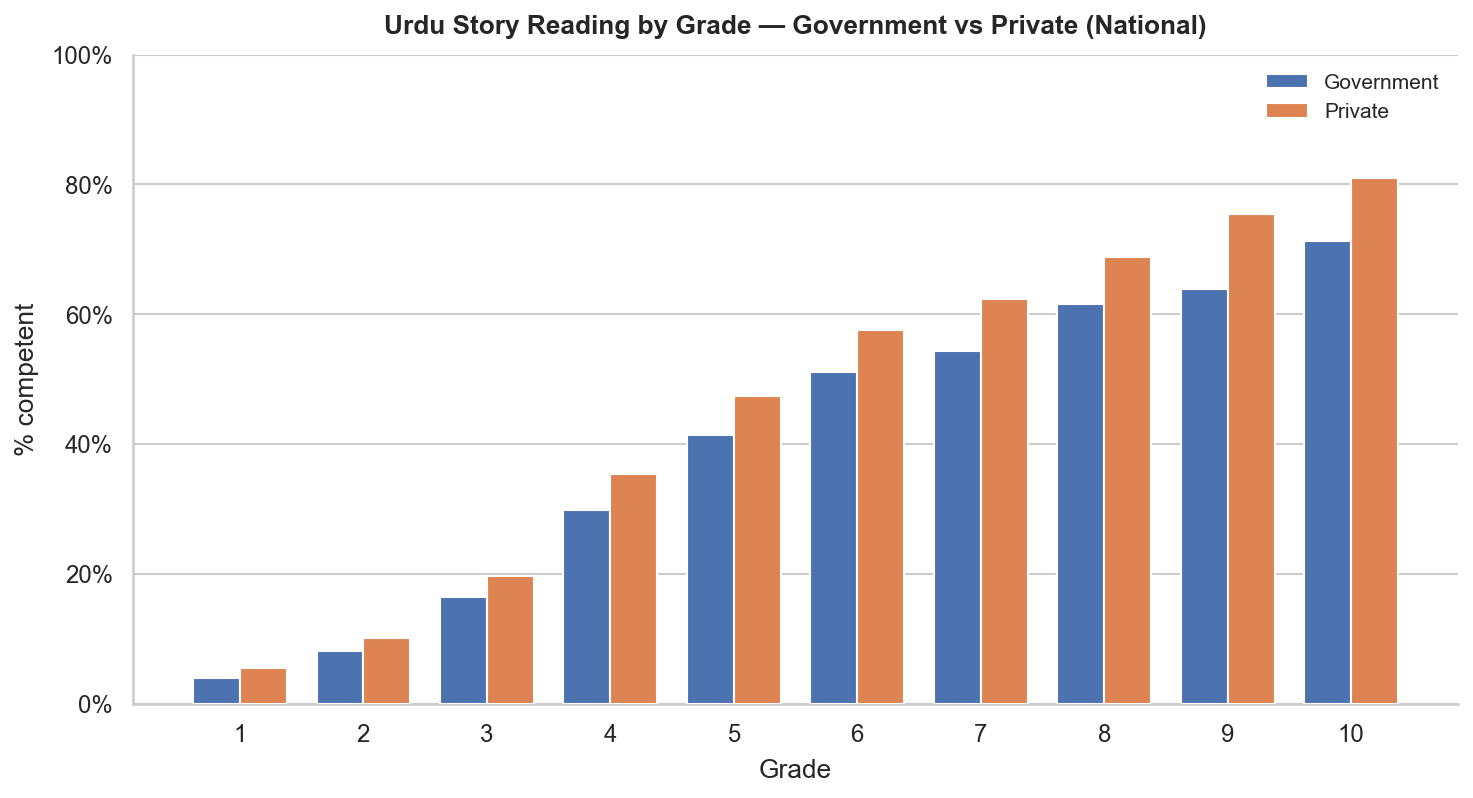

school_type  Government  Private  Gap (pvt−govt)
grade                                           
1                   3.9      5.5             1.6
2                   8.1     10.2             2.1
3                  16.5     19.6             3.1
4                  29.8     35.3             5.5
5                  41.3     47.4             6.1
6                  51.1     57.6             6.5
7                  54.4     62.3             7.9
8                  61.5     68.8             7.3
9                  63.9     75.4            11.5
10                 71.3     81.0             9.7


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
grouped_bar_chart(
    national, 'can_read_story_urdu', '% competent',
    'Urdu Story Reading by Grade — Government vs Private (National)', ax
)
plt.tight_layout()
fig.savefig(FIGURES / '05b_urdu_reading_national.png', bbox_inches='tight')
fig.savefig(FIGURES / '05b_urdu_reading_national.pdf', bbox_inches='tight')
plt.show()

tbl = national.pivot(index='grade', columns='school_type', values='can_read_story_urdu').round(1)
tbl['Gap (pvt−govt)'] = (tbl['Private'] - tbl['Government']).round(1)
print(tbl.to_string())

## Figure 3 — English Sentence Reading Competency by Grade: Government vs Private (National)

English sentence reading is the most demanding skill assessed and carries high stakes for economic mobility: access to higher education, white-collar employment, and digital services in Pakistan is largely gated by English proficiency. The private school advantage in English tends to be proportionally larger than in Urdu or arithmetic because many private schools explicitly market English-medium instruction.

Even by grade 10, fewer than 80% of private school students and around 70% of government school students can read simple English sentences — a reminder that both sectors leave substantial room for improvement, but government students begin from a significantly lower baseline at every grade.

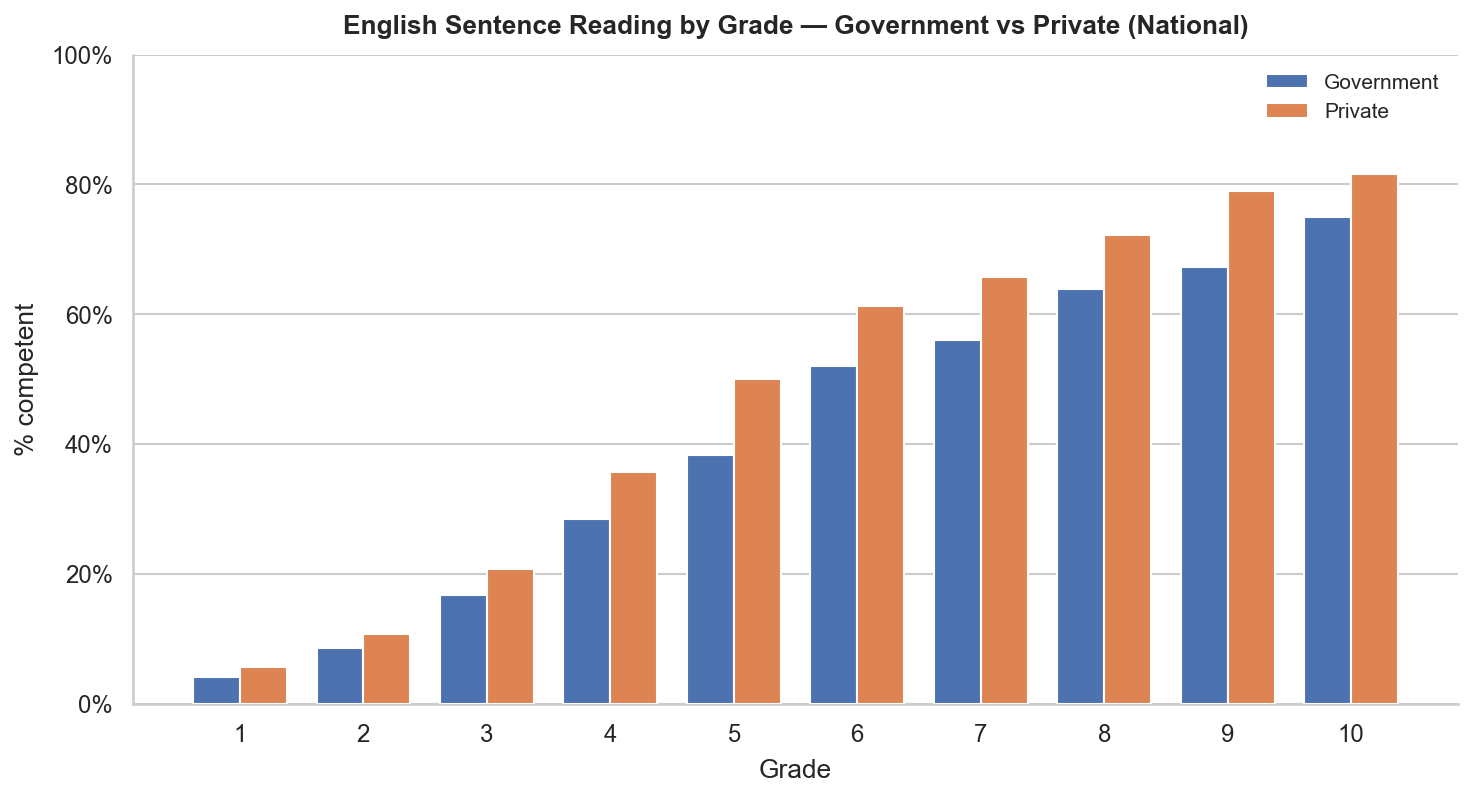

school_type  Government  Private  Gap (pvt−govt)
grade                                           
1                   4.2      5.7             1.5
2                   8.5     10.7             2.2
3                  16.7     20.7             4.0
4                  28.4     35.7             7.3
5                  38.4     50.0            11.6
6                  52.0     61.3             9.3
7                  56.0     65.7             9.7
8                  64.0     72.2             8.2
9                  67.3     79.0            11.7
10                 74.9     81.5             6.6


In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
grouped_bar_chart(
    national, 'can_read_sentences_english', '% competent',
    'English Sentence Reading by Grade — Government vs Private (National)', ax
)
plt.tight_layout()
fig.savefig(FIGURES / '05c_english_reading_national.png', bbox_inches='tight')
fig.savefig(FIGURES / '05c_english_reading_national.pdf', bbox_inches='tight')
plt.show()

tbl = national.pivot(index='grade', columns='school_type', values='can_read_sentences_english').round(1)
tbl['Gap (pvt−govt)'] = (tbl['Private'] - tbl['Government']).round(1)
print(tbl.to_string())

## Figure 4 — Division Competency by Province: Small Multiples

The national picture conceals sharp provincial heterogeneity. This small-multiples panel disaggregates division competency for the four most populous provinces.

**Points of interest before reading:**
- **KPK** shows a *reversed* gap at grades 4–6: government school students outperform private students in division. This is consistent with KPK's sustained investment in public school reform (the *Khyber Pakhtunkhwa Education Reforms* programme) and echoes district-level patterns visible in notebook 03.
- **Balochistan private school samples are small** (1,512 students across grades 1–10). Individual bars for private schools in this panel carry high sampling uncertainty and should be read with caution.
- **Punjab** shows the largest absolute rates across both sectors — consistent with its position as Pakistan's most urbanised and economically developed province.
- **Sindh** shows the largest persistent gap across all grades, with government school rates lagging well behind the national average at every grade level.

/var/folders/lq/rbhsx7wx1b37kxx7kqf__8t80000gn/T/ipykernel_36325/1767829622.py:40: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lq/rbhsx7wx1b37kxx7kqf__8t80000gn/T/ipykernel_36325/1767829622.py:42: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.savefig(FIGURES / '05d_division_competency_provinces.png', bbox_inches='tight')
/var/folders/lq/rbhsx7wx1b37kxx7kqf__8t80000gn/T/ipykernel_36325/1767829622.py:43: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.savefig(FIGURES / '05d_division_competency_provinces.pdf', bbox_inches='tight')
/Users/sherazhassan/Desktop/Education-inequality-Pakistan/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


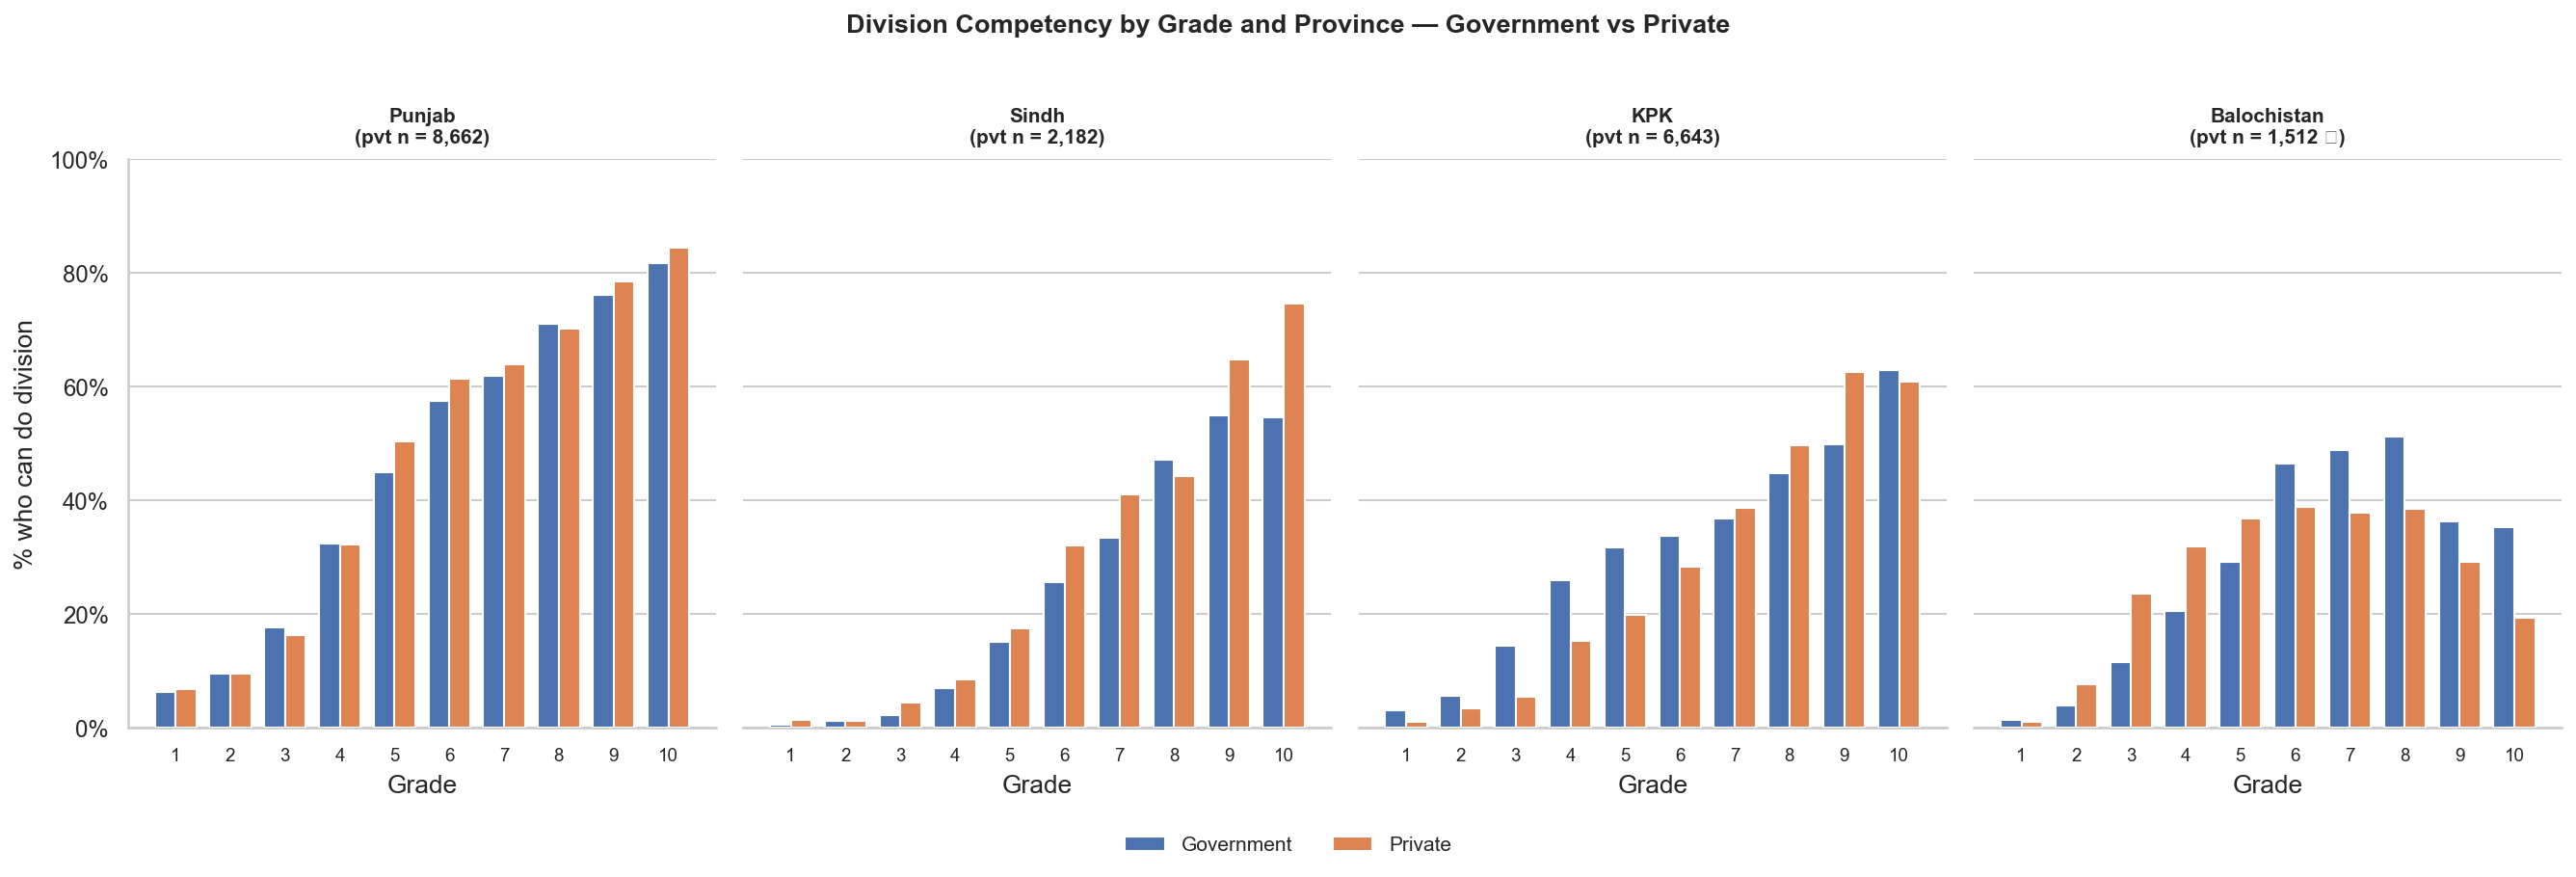


Punjab
school_type  Government  Private  Gap
grade                                
1                   6.4      6.9  0.5
2                   9.5      9.6  0.1
3                  17.6     16.4 -1.2
4                  32.4     32.2 -0.2
5                  44.9     50.4  5.5
6                  57.6     61.4  3.8
7                  61.9     64.0  2.1
8                  71.1     70.2 -0.9
9                  76.1     78.5  2.4
10                 81.8     84.4  2.6

Sindh
school_type  Government  Private   Gap
grade                                 
1                   0.7      1.3   0.6
2                   1.2      1.2   0.0
3                   2.3      4.4   2.1
4                   7.0      8.6   1.6
5                  15.2     17.4   2.2
6                  25.7     32.1   6.4
7                  33.5     41.1   7.6
8                  47.1     44.2  -2.9
9                  54.9     64.8   9.9
10                 54.6     74.6  20.0

KPK
school_type  Government  Private   Gap
grade            

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), sharey=True)

for ax, prov in zip(axes, PROVINCES_SM):
    sub = province_div[province_div['province'] == prov]
    govt_pct = sub[sub['school_type'] == 'Government'].set_index('grade')['pct']
    pvt_pct  = sub[sub['school_type'] == 'Private'].set_index('grade')['pct']
    pvt_n_prov = pvt_n.get(prov, 0)

    x = np.arange(len(GRADES))
    w = 0.38
    ax.bar(x - w / 2, [govt_pct.get(g, np.nan) for g in GRADES],
           width=w, color=GOVT_COLOR, zorder=3)
    ax.bar(x + w / 2, [pvt_pct.get(g, np.nan) for g in GRADES],
           width=w, color=PVT_COLOR, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(GRADES, fontsize=9)
    ax.set_xlabel('Grade', labelpad=5)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=(ax != axes[0]))

    # Title: flag small private sample
    n_note = f'\n(pvt n = {pvt_n_prov:,} ⚠)' if pvt_n_prov < 2000 else f'\n(pvt n = {pvt_n_prov:,})'
    ax.set_title(prov + n_note, fontweight='bold', fontsize=10, pad=8)

axes[0].set_ylabel('% who can do division', labelpad=6)

# Shared legend
handles = [
    mpatches.Patch(facecolor=GOVT_COLOR, label='Government'),
    mpatches.Patch(facecolor=PVT_COLOR,  label='Private'),
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10)
fig.suptitle('Division Competency by Grade and Province — Government vs Private',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

fig.savefig(FIGURES / '05d_division_competency_provinces.png', bbox_inches='tight')
fig.savefig(FIGURES / '05d_division_competency_provinces.pdf', bbox_inches='tight')
plt.show()

# Print underlying numbers for the four provinces
for prov in PROVINCES_SM:
    tbl = (province_div[province_div['province'] == prov]
           .pivot(index='grade', columns='school_type', values='pct')
           .round(1))
    tbl['Gap'] = (tbl.get('Private', np.nan) - tbl.get('Government', np.nan)).round(1)
    print(f'\n{prov}')
    print(tbl.to_string())